In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import basis, expect, mesolve, qeye, sigmax, sigmay, sigmaz, tensor

# Exercise 30

In [2]:
# Function to compute expectation values for a given state
def compute_expectation_values(state, operators):
    expectation_values = []
    for operator in operators:
        expectation_values.append(expect(operator, state))
    return expectation_values

In [3]:
# Define Pauli operators
X = sigmax()  # Pauli-X
Y = sigmay()  # Pauli-Y
Z = sigmaz()  # Pauli-Z
I = qeye(2)  # Identity operator

# Define the states
# |+A> = (|0> + |1>)/sqrt(2), |-B> = (|0> - |1>)/sqrt(2)
state_plus_minus = tensor(
    (basis(2, 0) + basis(2, 1)).unit(), (basis(2, 0) - basis(2, 1)).unit()
)

# Bell state |B3> = (|00> + |11>)/sqrt(2)
state_B3 = (tensor(basis(2, 0), basis(2, 0)) + tensor(basis(2, 1), basis(2, 1))).unit()

# Pauli operators
pauli_operators = [
    tensor(X, I),
    tensor(I, X),
    tensor(X, X),
    tensor(Y, I),
    tensor(I, Y),
    tensor(Y, Y),
    tensor(Z, I),
    tensor(I, Z),
    tensor(Z, Z),
    tensor(I, I),
]


# Compute the expectation values for both states
expectation_values_plus_minus = compute_expectation_values(
    state_plus_minus, pauli_operators
)
expectation_values_B3 = compute_expectation_values(state_B3, pauli_operators)

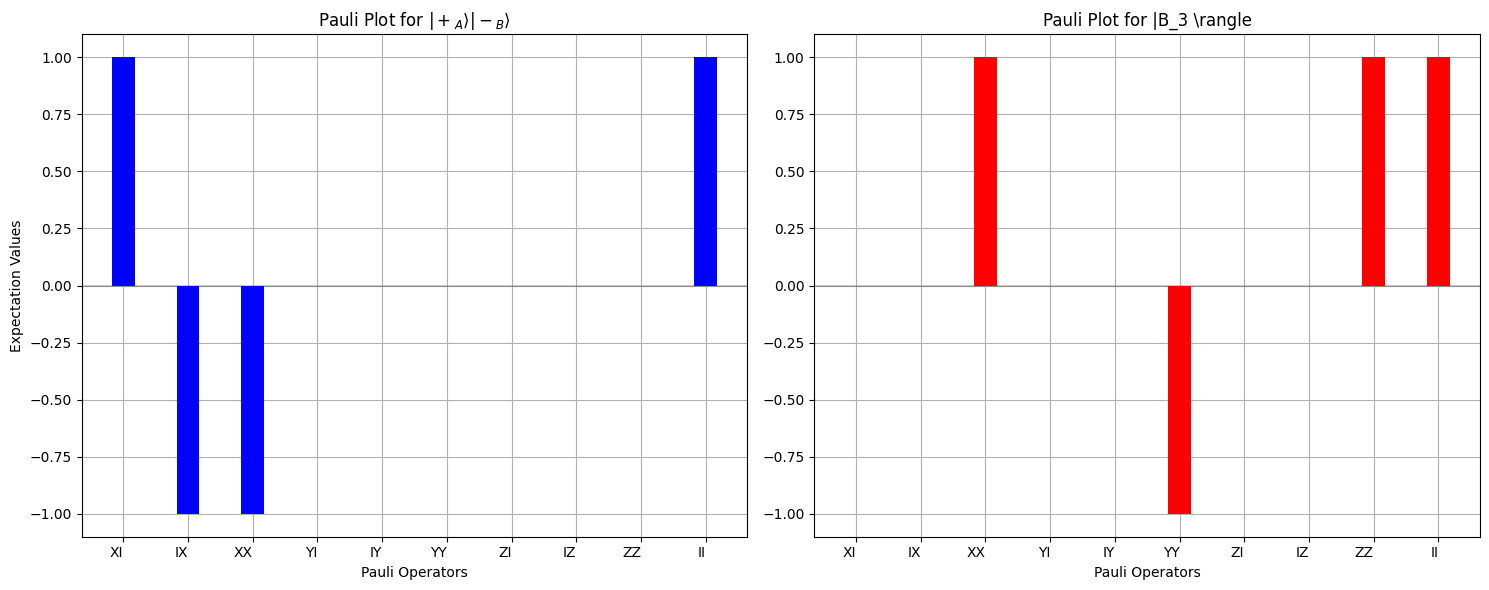

In [4]:
# Create two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Define the bar width
bar_width = 0.35
index = np.arange(len(pauli_operators))

# Plot the bars for |+A>|-B> in the first subplot
ax1.grid(True)
ax1.axhline(0, color="black", linestyle="-", alpha=0.2)
ax1.bar(
    index, expectation_values_plus_minus, bar_width, color="b", align="center", zorder=3
)
ax1.set_xlabel("Pauli Operators")
ax1.set_ylabel("Expectation Values")
ax1.set_title(r"Pauli Plot for $|+_A \rangle|-_B \rangle$")
ax1.set_xticks(index)
ax1.set_xticklabels(
    ["XI", "IX", "XX", "YI", "IY", "YY", "ZI", "IZ", "ZZ", "II"], rotation=0, ha="right"
)

# Plot the bars for |B3> in the second subplot
ax2.grid(True)
ax2.axhline(0, color="black", linestyle="-", alpha=0.2)
ax2.bar(
    index,
    expectation_values_B3,
    bar_width,
    label="|B3>",
    color="r",
    align="center",
    zorder=3,
)
ax2.set_xlabel("Pauli Operators")
ax2.set_title(r"Pauli Plot for |B_3 \rangle")
ax2.set_xticks(index)
ax2.set_xticklabels(
    ["XI", "IX", "XX", "YI", "IY", "YY", "ZI", "IZ", "ZZ", "II"], rotation=0, ha="right"
)

# Adjust layout
plt.tight_layout()
plt.savefig("ex30")
plt.show()

# Exercise 33

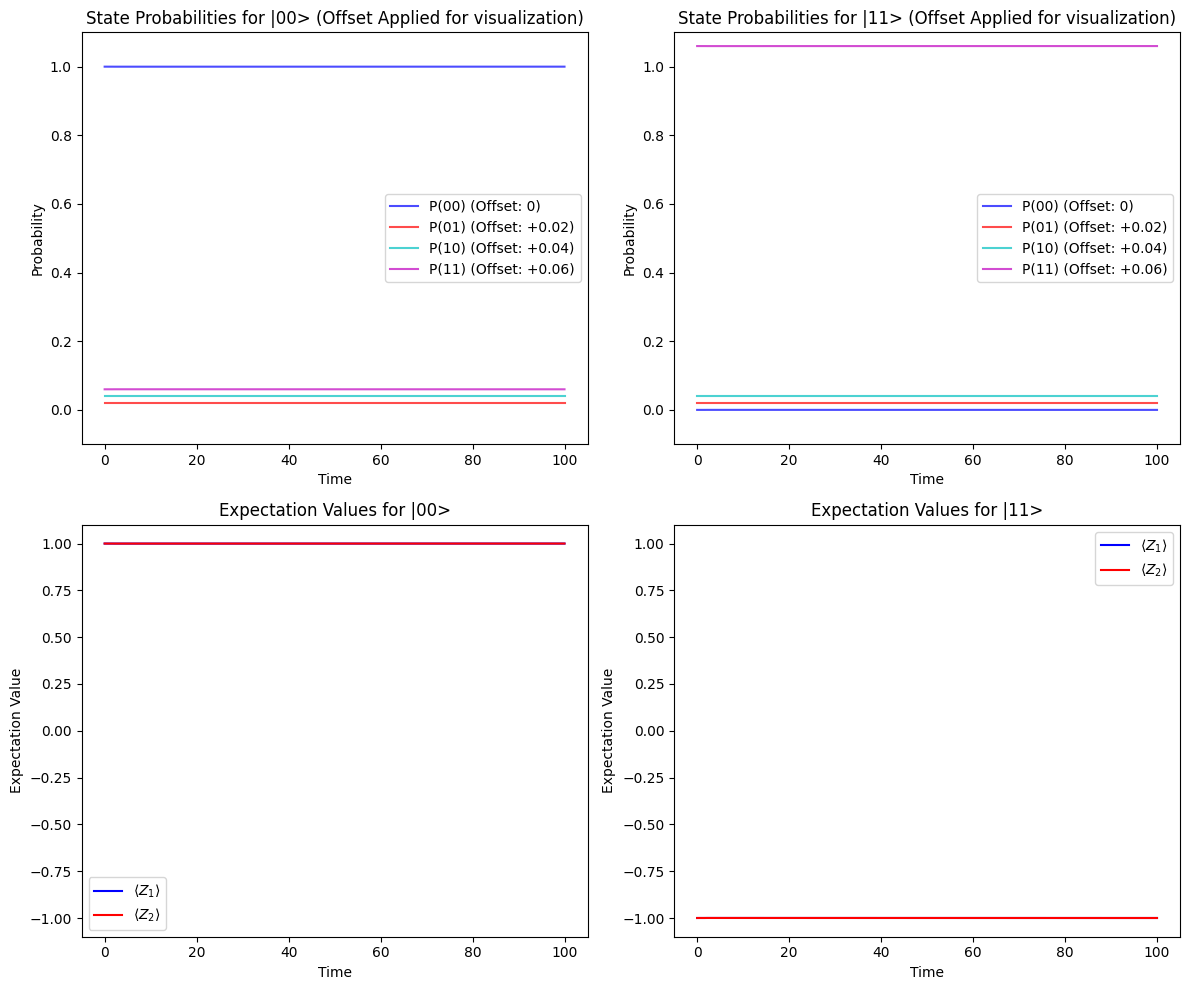

In [5]:
# Parameters
omega1 = 2 * np.pi  # Frequency for qubit 1
omega2 = 2 * np.pi  # Frequency for qubit 2
g = 2 * np.pi / 100  # Interaction strength
tlist = np.linspace(0, 100, 1001)  # Time evolution from 0 to 100

# Pauli matrices for two qubits
Z1 = tensor(Z, I)  # Z operator on qubit 1
Z2 = tensor(I, Z)  # Z operator on qubit 2
X1 = tensor(X, I)  # X operator on qubit 1
X2 = tensor(I, X)  # X operator on qubit 2

# Define the Hamiltonian
H = -0.5 * omega1 * Z1 - 0.5 * omega2 * Z2 + g * X1 * X2

# Initial states
psi_00 = tensor(basis(2, 0), basis(2, 0))  # |00>
psi_11 = tensor(basis(2, 1), basis(2, 1))  # |11>

# Time evolution for |00>
result_00 = mesolve(H, psi_00, tlist, [], [Z1, Z2], options={"store_states": True})
expect_00_0 = result_00.expect[0]
expect_00_1 = result_00.expect[1]

# Time evolution for |11>
result_11 = mesolve(H, psi_11, tlist, [], [Z1, Z2], options={"store_states": True})
expect_11_0 = result_11.expect[0]
expect_11_1 = result_11.expect[1]

# Probability of states |00>, |01>, |10>, |11> over time
P_00_00 = np.array([np.abs(state.overlap(tensor(basis(2, 0), basis(2, 0))))**2 for state in result_00.states])
P_01_00 = np.array([np.abs(state.overlap(tensor(basis(2, 0), basis(2, 1))))**2 for state in result_00.states])
P_10_00 = np.array([np.abs(state.overlap(tensor(basis(2, 1), basis(2, 0))))**2 for state in result_00.states])
P_11_00 = np.array([np.abs(state.overlap(tensor(basis(2, 1), basis(2, 1))))**2 for state in result_00.states])

P_00_11 = np.array([np.abs(state.overlap(tensor(basis(2, 0), basis(2, 0))))**2 for state in result_11.states])
P_01_11 = np.array([np.abs(state.overlap(tensor(basis(2, 0), basis(2, 1))))**2 for state in result_11.states])
P_10_11 = np.array([np.abs(state.overlap(tensor(basis(2, 1), basis(2, 0))))**2 for state in result_11.states])
P_11_11 = np.array([np.abs(state.overlap(tensor(basis(2, 1), basis(2, 1))))**2 for state in result_11.states])

# Offset values
offsets = {"P(00)": 0, "P(01)": 0.02, "P(10)": 0.04, "P(11)": 0.06}

# Apply offsets to probabilities
P_00_00 += offsets["P(00)"]
P_01_00 += offsets["P(01)"]
P_10_00 += offsets["P(10)"]
P_11_00 += offsets["P(11)"]

P_00_11 += offsets["P(00)"]
P_01_11 += offsets["P(01)"]
P_10_11 += offsets["P(10)"]
P_11_11 += offsets["P(11)"]

# Plotting the results with 4 subplots in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Left column: |00> state
# 1. Probabilities P(00), P(01), P(10), P(11) for |00>
axes[0, 0].plot(tlist, P_00_00, label="P(00) (Offset: 0)", color="b", alpha=0.7)
axes[0, 0].plot(tlist, P_01_00, label="P(01) (Offset: +0.02)", color="r", alpha=0.7)
axes[0, 0].plot(tlist, P_10_00, label="P(10) (Offset: +0.04)", color="c", alpha=0.7)
axes[0, 0].plot(tlist, P_11_00, label="P(11) (Offset: +0.06)", color="m", alpha=0.7)
axes[0, 0].set_title("State Probabilities for |00> (Offset Applied for visualization)")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("Probability")
axes[0, 0].set_ylim(-0.1, 1.1)
axes[0, 0].legend()

# 2. Expectation values of Z0 and Z1 for |00>
axes[1, 0].plot(tlist, expect_00_0, label=r"$\langle Z_1 \rangle$", color="b")
axes[1, 0].plot(tlist, expect_00_1, label=r"$\langle Z_2 \rangle$", color="r")
axes[1, 0].set_title("Expectation Values for |00>")
axes[1, 0].set_xlabel("Time")
axes[1, 0].set_ylabel("Expectation Value")
axes[1, 0].set_ylim(-1.1, 1.1)
axes[1, 0].legend()

# Right column: |11> state
# 1. Probabilities P(00), P(01), P(10), P(11) for |11>
axes[0, 1].plot(tlist, P_00_11, label="P(00) (Offset: 0)", color="b", alpha=0.7)
axes[0, 1].plot(tlist, P_01_11, label="P(01) (Offset: +0.02)", color="r", alpha=0.7)
axes[0, 1].plot(tlist, P_10_11, label="P(10) (Offset: +0.04)", color="c", alpha=0.7)
axes[0, 1].plot(tlist, P_11_11, label="P(11) (Offset: +0.06)", color="m", alpha=0.7)
axes[0, 1].set_title("State Probabilities for |11> (Offset Applied for visualization)")
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel("Probability")
axes[0, 1].set_ylim(-0.1, 1.1)
axes[0, 1].legend()

# 2. Expectation values of Z0 and Z1 for |11>
axes[1, 1].plot(tlist, expect_11_0, label=r"$\langle Z_1 \rangle$", color="b")
axes[1, 1].plot(tlist, expect_11_1, label=r"$\langle Z_2 \rangle$", color="r")
axes[1, 1].set_title("Expectation Values for |11>")
axes[1, 1].set_xlabel("Time")
axes[1, 1].set_ylabel("Expectation Value")
axes[1, 1].set_ylim(-1.1, 1.1)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("ex33")
plt.show()


# Exercise 34

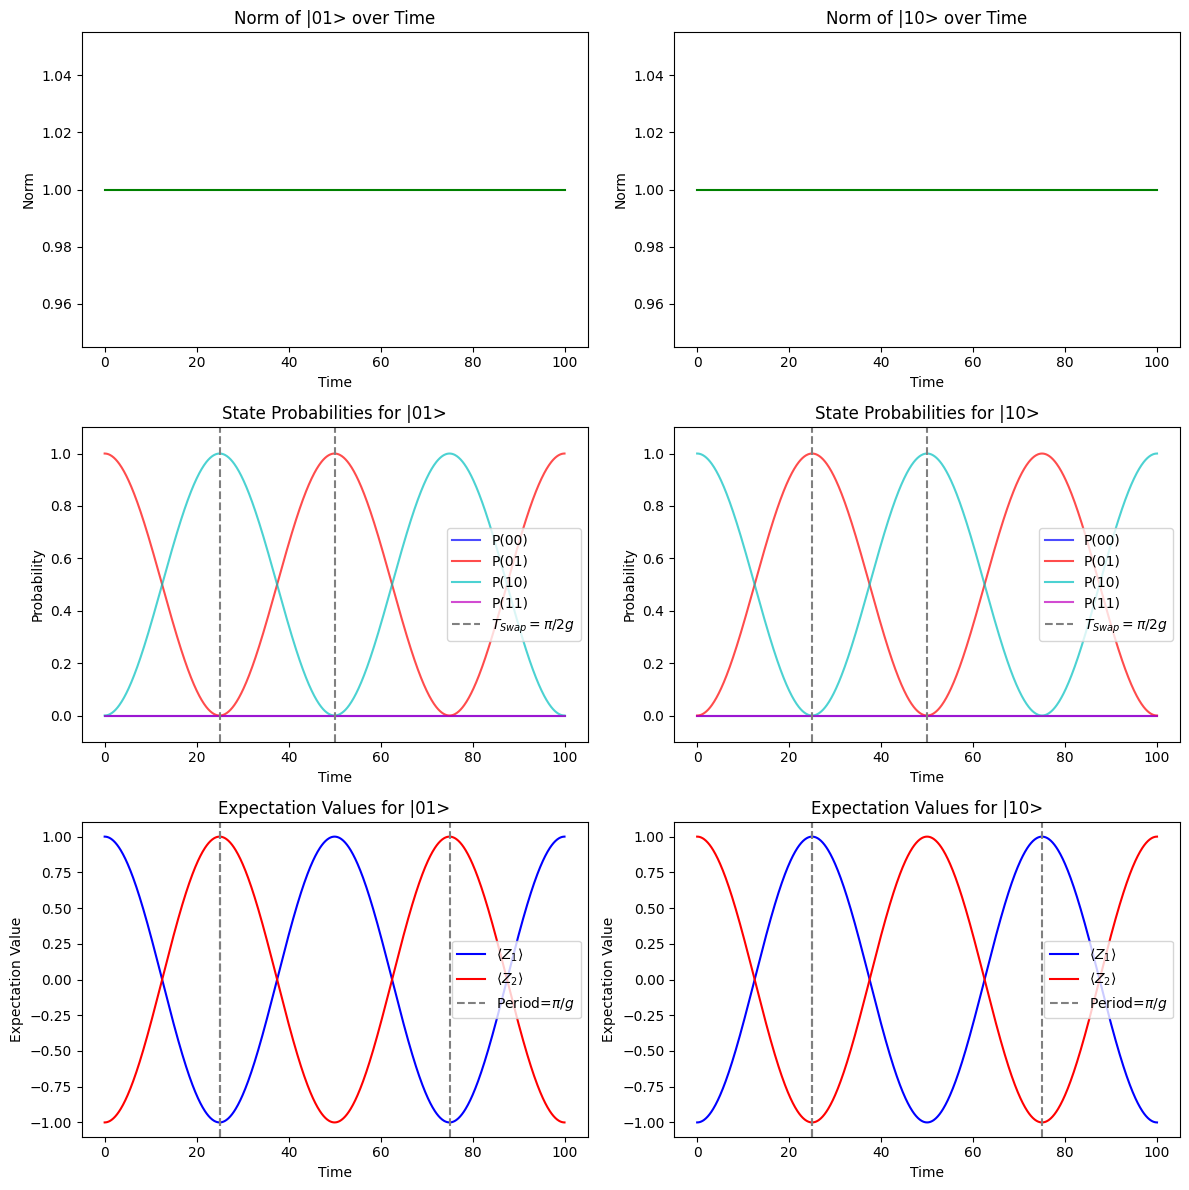

In [7]:
# Define initial states |01> and |10>
psi_01 = tensor(basis(2, 0), basis(2, 1))  # |01>
psi_10 = tensor(basis(2, 1), basis(2, 0))  # |10>

# Time evolution for |01>
result_01 = mesolve(H, psi_01, tlist, [], [Z1, Z2], options={"store_states": True})
expect_01_0 = result_01.expect[0]  # ⟨Z1⟩ for |01>
expect_01_1 = result_01.expect[1]  # ⟨Z2⟩ for |01>

# Time evolution for |10>
result_10 = mesolve(H, psi_10, tlist, [], [Z1, Z2], options={"store_states": True})
expect_10_0 = result_10.expect[0]  # ⟨Z1⟩ for |10>
expect_10_1 = result_10.expect[1]  # ⟨Z2⟩ for |10>

# Compute probabilities of states |00>, |01>, |10>, |11> over time for |01> and |10>
P_00_01 = np.array([np.abs(state.overlap(tensor(basis(2, 0), basis(2, 0))))**2 for state in result_01.states])
P_01_01 = np.array([np.abs(state.overlap(tensor(basis(2, 0), basis(2, 1))))**2 for state in result_01.states])
P_10_01 = np.array([np.abs(state.overlap(tensor(basis(2, 1), basis(2, 0))))**2 for state in result_01.states])
P_11_01 = np.array([np.abs(state.overlap(tensor(basis(2, 1), basis(2, 1))))**2 for state in result_01.states])

P_00_10 = np.array([np.abs(state.overlap(tensor(basis(2, 0), basis(2, 0))))**2 for state in result_10.states])
P_01_10 = np.array([np.abs(state.overlap(tensor(basis(2, 0), basis(2, 1))))**2 for state in result_10.states])
P_10_10 = np.array([np.abs(state.overlap(tensor(basis(2, 1), basis(2, 0))))**2 for state in result_10.states])
P_11_10 = np.array([np.abs(state.overlap(tensor(basis(2, 1), basis(2, 1))))**2 for state in result_10.states])

# Plot results with a 3x2 grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# Left column: Results for |01>
# 1. Norm of |01>
axes[0, 0].plot(tlist, [state.norm() for state in result_01.states], color="g")
axes[0, 0].set(title="Norm of |01> over Time", xlabel="Time", ylabel="Norm")

# 2. Probabilities P(00), P(01), P(10), P(11) for |01>
axes[1, 0].plot(tlist, P_00_01, label="P(00)", color="b", alpha=0.7)
axes[1, 0].plot(tlist, P_01_01, label="P(01)", color="r", alpha=0.7)
axes[1, 0].plot(tlist, P_10_01, label="P(10)", color="c", alpha=0.7)
axes[1, 0].plot(tlist, P_11_01, label="P(11)", color="m", alpha=0.7)
axes[1, 0].axvline(np.pi / (2 * g), color="gray", linestyle="--", label=r"$T_{Swap}=\pi/2g$")
axes[1, 0].axvline(np.pi / g, color="gray", linestyle="--")
axes[1, 0].set(title="State Probabilities for |01>", xlabel="Time", ylabel="Probability", ylim=(-0.1, 1.1))
axes[1, 0].legend()

# 3. Expectation values ⟨Z1⟩, ⟨Z2⟩ for |01>
axes[2, 0].plot(tlist, expect_01_0, label=r"$\langle Z_1 \rangle$", color="b")
axes[2, 0].plot(tlist, expect_01_1, label=r"$\langle Z_2 \rangle$", color="r")
axes[2, 0].axvline(np.pi / (2 * g), color="gray", linestyle="--")
axes[2, 0].set(title="Expectation Values for |01>", xlabel="Time", ylabel="Expectation Value", ylim=(-1.1, 1.1))
axes[2, 0].axvline(np.pi/(2*g), color='gray', linestyle='--')
axes[2, 0].axvline((3*np.pi)/(2*g), color='gray', linestyle='--', label='Period=$\pi/g$')
axes[2, 0].legend()

# Right column: Results for |10>
# 1. Norm of |10>
axes[0, 1].plot(tlist, [state.norm() for state in result_10.states], color="g")
axes[0, 1].set(title="Norm of |10> over Time", xlabel="Time", ylabel="Norm")

# 2. Probabilities P(00), P(01), P(10), P(11) for |10>
axes[1, 1].plot(tlist, P_00_10, label="P(00)", color="b", alpha=0.7)
axes[1, 1].plot(tlist, P_01_10, label="P(01)", color="r", alpha=0.7)
axes[1, 1].plot(tlist, P_10_10, label="P(10)", color="c", alpha=0.7)
axes[1, 1].plot(tlist, P_11_10, label="P(11)", color="m", alpha=0.7)
axes[1, 1].axvline(np.pi / (2 * g), color="gray", linestyle="--", label=r"$T_{Swap}=\pi/2g$")
axes[1, 1].axvline(np.pi / g, color="gray", linestyle="--")
axes[1, 1].set(title="State Probabilities for |10>", xlabel="Time", ylabel="Probability", ylim=(-0.1, 1.1))
axes[1, 1].legend()

# 3. Expectation values ⟨Z1⟩, ⟨Z2⟩ for |10>
axes[2, 1].plot(tlist, expect_10_0, label=r"$\langle Z_1 \rangle$", color="b")
axes[2, 1].plot(tlist, expect_10_1, label=r"$\langle Z_2 \rangle$", color="r")
axes[2, 1].axvline(np.pi / (2 * g), color="gray", linestyle="--")
axes[2, 1].set(title="Expectation Values for |10>", xlabel="Time", ylabel="Expectation Value", ylim=(-1.1, 1.1))
axes[2, 1].axvline(np.pi/(2*g), color='gray', linestyle='--')
axes[2, 1].axvline((3*np.pi)/(2*g), color='gray', linestyle='--', label='Period=$\pi/g$')
axes[2, 1].legend()

# Adjust layout and save the plot
plt.tight_layout()
plt.savefig("ex34")
plt.show()

# Exercise 35

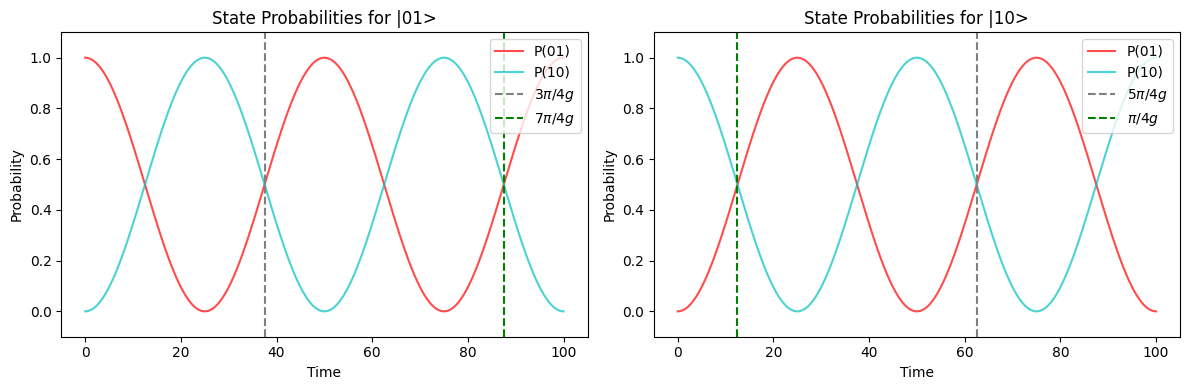

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(tlist, P_01_01, label="P(01)", color="r", alpha=0.7)
axes[0].plot(tlist, P_10_01, label="P(10)", color="c", alpha=0.7)
axes[0].axvline((np.pi / g)*(1-1/4), color="gray", linestyle="--", label=r"$3\pi/4g$")
axes[0].axvline((np.pi / g)*(1+1/2 + 1/4), color="green", linestyle="--", label=r"$7\pi/4g$")

axes[0].set(title="State Probabilities for |01>", xlabel="Time", ylabel="Probability", ylim=(-0.1, 1.1))
axes[0].legend(loc='upper right')

axes[1].plot(tlist, P_01_10, label="P(01)", color="r", alpha=0.7)
axes[1].plot(tlist, P_10_10, label="P(10)", color="c", alpha=0.7)
axes[1].set(title="State Probabilities for |10>", xlabel="Time", ylabel="Probability", ylim=(-0.1, 1.1))
axes[1].axvline((np.pi / g)*(1+1/4), color="gray", linestyle="--", label=r"$5\pi/4g$")
axes[1].axvline((np.pi / g)*(1-1/2-1/4), color="green", linestyle="--", label=r"$\pi/4g$")
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig("ex35")
plt.show()

In [89]:
states = np.array([state.full().flatten() for state in result_01.states])

# |01⟩ + i|10⟩
sv1 = (tensor(basis(2, 0), basis(2, 1)) + 1j * tensor(basis(2, 1), basis(2, 0))).full().flatten()
sv1 /= np.linalg.norm(sv1)

# |01⟩ - i|10⟩
sv2 = (tensor(basis(2, 0), basis(2, 1)) - 1j * tensor(basis(2, 1), basis(2, 0))).full().flatten()
sv2 /= np.linalg.norm(sv2)

# compute fidelity of every state with sv1 and sv2
fids_1 = np.abs(np.conj(states) @ sv1)**2
fids_2 = np.abs(np.conj(states) @ sv2)**2

# find time with highest fidelity for sv1
ts = np.argsort(np.abs((fids_1 - 1)))[:2]

print("Results with |01⟩ + i|10⟩")
print(f"Theoritical time: {3 * np.pi / (4 * g):.3f}, {7 * np.pi / (4 * g):.3f}")
print(f"Calculated time: {tlist[ts[1]]:.3f}, {tlist[ts[0]]:.3f}")

display(result_01.states[ts[0]])
display(result_01.states[ts[1]])

# find time with highest fidelity for sv2
ts = np.argsort(np.abs((fids_2 - 1)))[:2]

print("Results with |01⟩ - i|10⟩")
print(f"Theoritical time: {np.pi / (4 * g):.3f}, {5 * np.pi / (4 * g):.3f}")
print(f"Calculated time: {tlist[ts[0]]:.3f}, {tlist[ts[1]]:.3f}")

display(result_01.states[ts[0]])
display(result_01.states[ts[1]])

Results with |01⟩ + i|10⟩
Theoritical time: 37.500, 87.500
Calculated time: 37.500, 87.500


Quantum object: dims=[[2, 2], [1, 1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.        +0.j        ]
 [0.70710753+0.j        ]
 [0.        +0.70710603j]
 [0.        +0.j        ]]

Quantum object: dims=[[2, 2], [1, 1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.        +0.j        ]
 [-0.70710823+0.j        ]
 [ 0.        -0.70710533j]
 [ 0.        +0.j        ]]

Results with |01⟩ - i|10⟩
Theoritical time: 12.500, 62.500
Calculated time: 12.500, 62.500


Quantum object: dims=[[2, 2], [1, 1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.        +0.j        ]
 [0.70710663+0.j        ]
 [0.        -0.70710694j]
 [0.        +0.j        ]]

Quantum object: dims=[[2, 2], [1, 1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.        +0.j        ]
 [-0.70710442+0.j        ]
 [ 0.        +0.70710914j]
 [ 0.        +0.j        ]]